# 1.0 - Pooling Cross Sections across Time: Simple Panel Data Methods

## 1.1 - Pooling Independent Cross Sections across Time (Pooled OLS)

###Example 1.1 - Women's Fertility over Time

####Data desciption

Dataset comes from the National Opinion Research Center's General Social Survey for the even years from 1972 to 1984.
<br><br>
Estimation:
Estimate the model explaining the total number of kids born to a woman.
<br><br>
Research question: What happened to fertility rates over time?
<br><br>
Controls: Years of education, age, race, region of the country, and living environment at age 16.
<br><br>
Interest variables: Time dummy variables.
1972 (reference category), 74, 76, 78, 80, 82, 84.

#### Import Libraries and Dataset(s)

In [ ]:
# import libraries
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# import data
fertil = pd.read_stata('/content/drive/MyDrive/Colab Notebooks/PM I/Data/FERTIL1.dta')

#### Explore the dataset

In [ ]:
# Quick overview of the structure of the DataFrame: Index range, Column names and data types, Non-null counts, Memory usage
fertil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1129 entries, 0 to 1128
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   year      1129 non-null   int8 
 1   educ      1129 non-null   int8 
 2   meduc     1129 non-null   int8 
 3   feduc     1129 non-null   int8 
 4   age       1129 non-null   int8 
 5   kids      1129 non-null   int8 
 6   black     1129 non-null   int8 
 7   east      1129 non-null   int8 
 8   northcen  1129 non-null   int8 
 9   west      1129 non-null   int8 
 10  farm      1129 non-null   int8 
 11  othrural  1129 non-null   int8 
 12  town      1129 non-null   int8 
 13  smcity    1129 non-null   int8 
 14  y74       1129 non-null   int8 
 15  y76       1129 non-null   int8 
 16  y78       1129 non-null   int8 
 17  y80       1129 non-null   int8 
 18  y82       1129 non-null   int8 
 19  y84       1129 non-null   int8 
 20  agesq     1129 non-null   int16
 21  y74educ   1129 non-null   int8 
 22  

In [ ]:
# Display the first five rows of the dataset
# Show all columns in output
pd.set_option('display.max_columns', None)
# Now this will show all columns
fertil.head()

,year,educ,meduc,feduc,age,kids,black,east,northcen,west,farm,othrural,town,smcity,y74,y76,y78,y80,y82,y84,agesq,y74educ,y76educ,y78educ,y80educ,y82educ,y84educ
0,72,12,8,8,48,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2304,0,0,0,0,0,0
1,72,17,8,18,46,3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2116,0,0,0,0,0,0
2,72,12,7,8,53,2,0,0,1,0,0,1,0,0,0,0,0,0,0,0,2809,0,0,0,0,0,0
3,72,12,12,10,42,2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1764,0,0,0,0,0,0
4,72,12,3,8,51,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2601,0,0,0,0,0,0


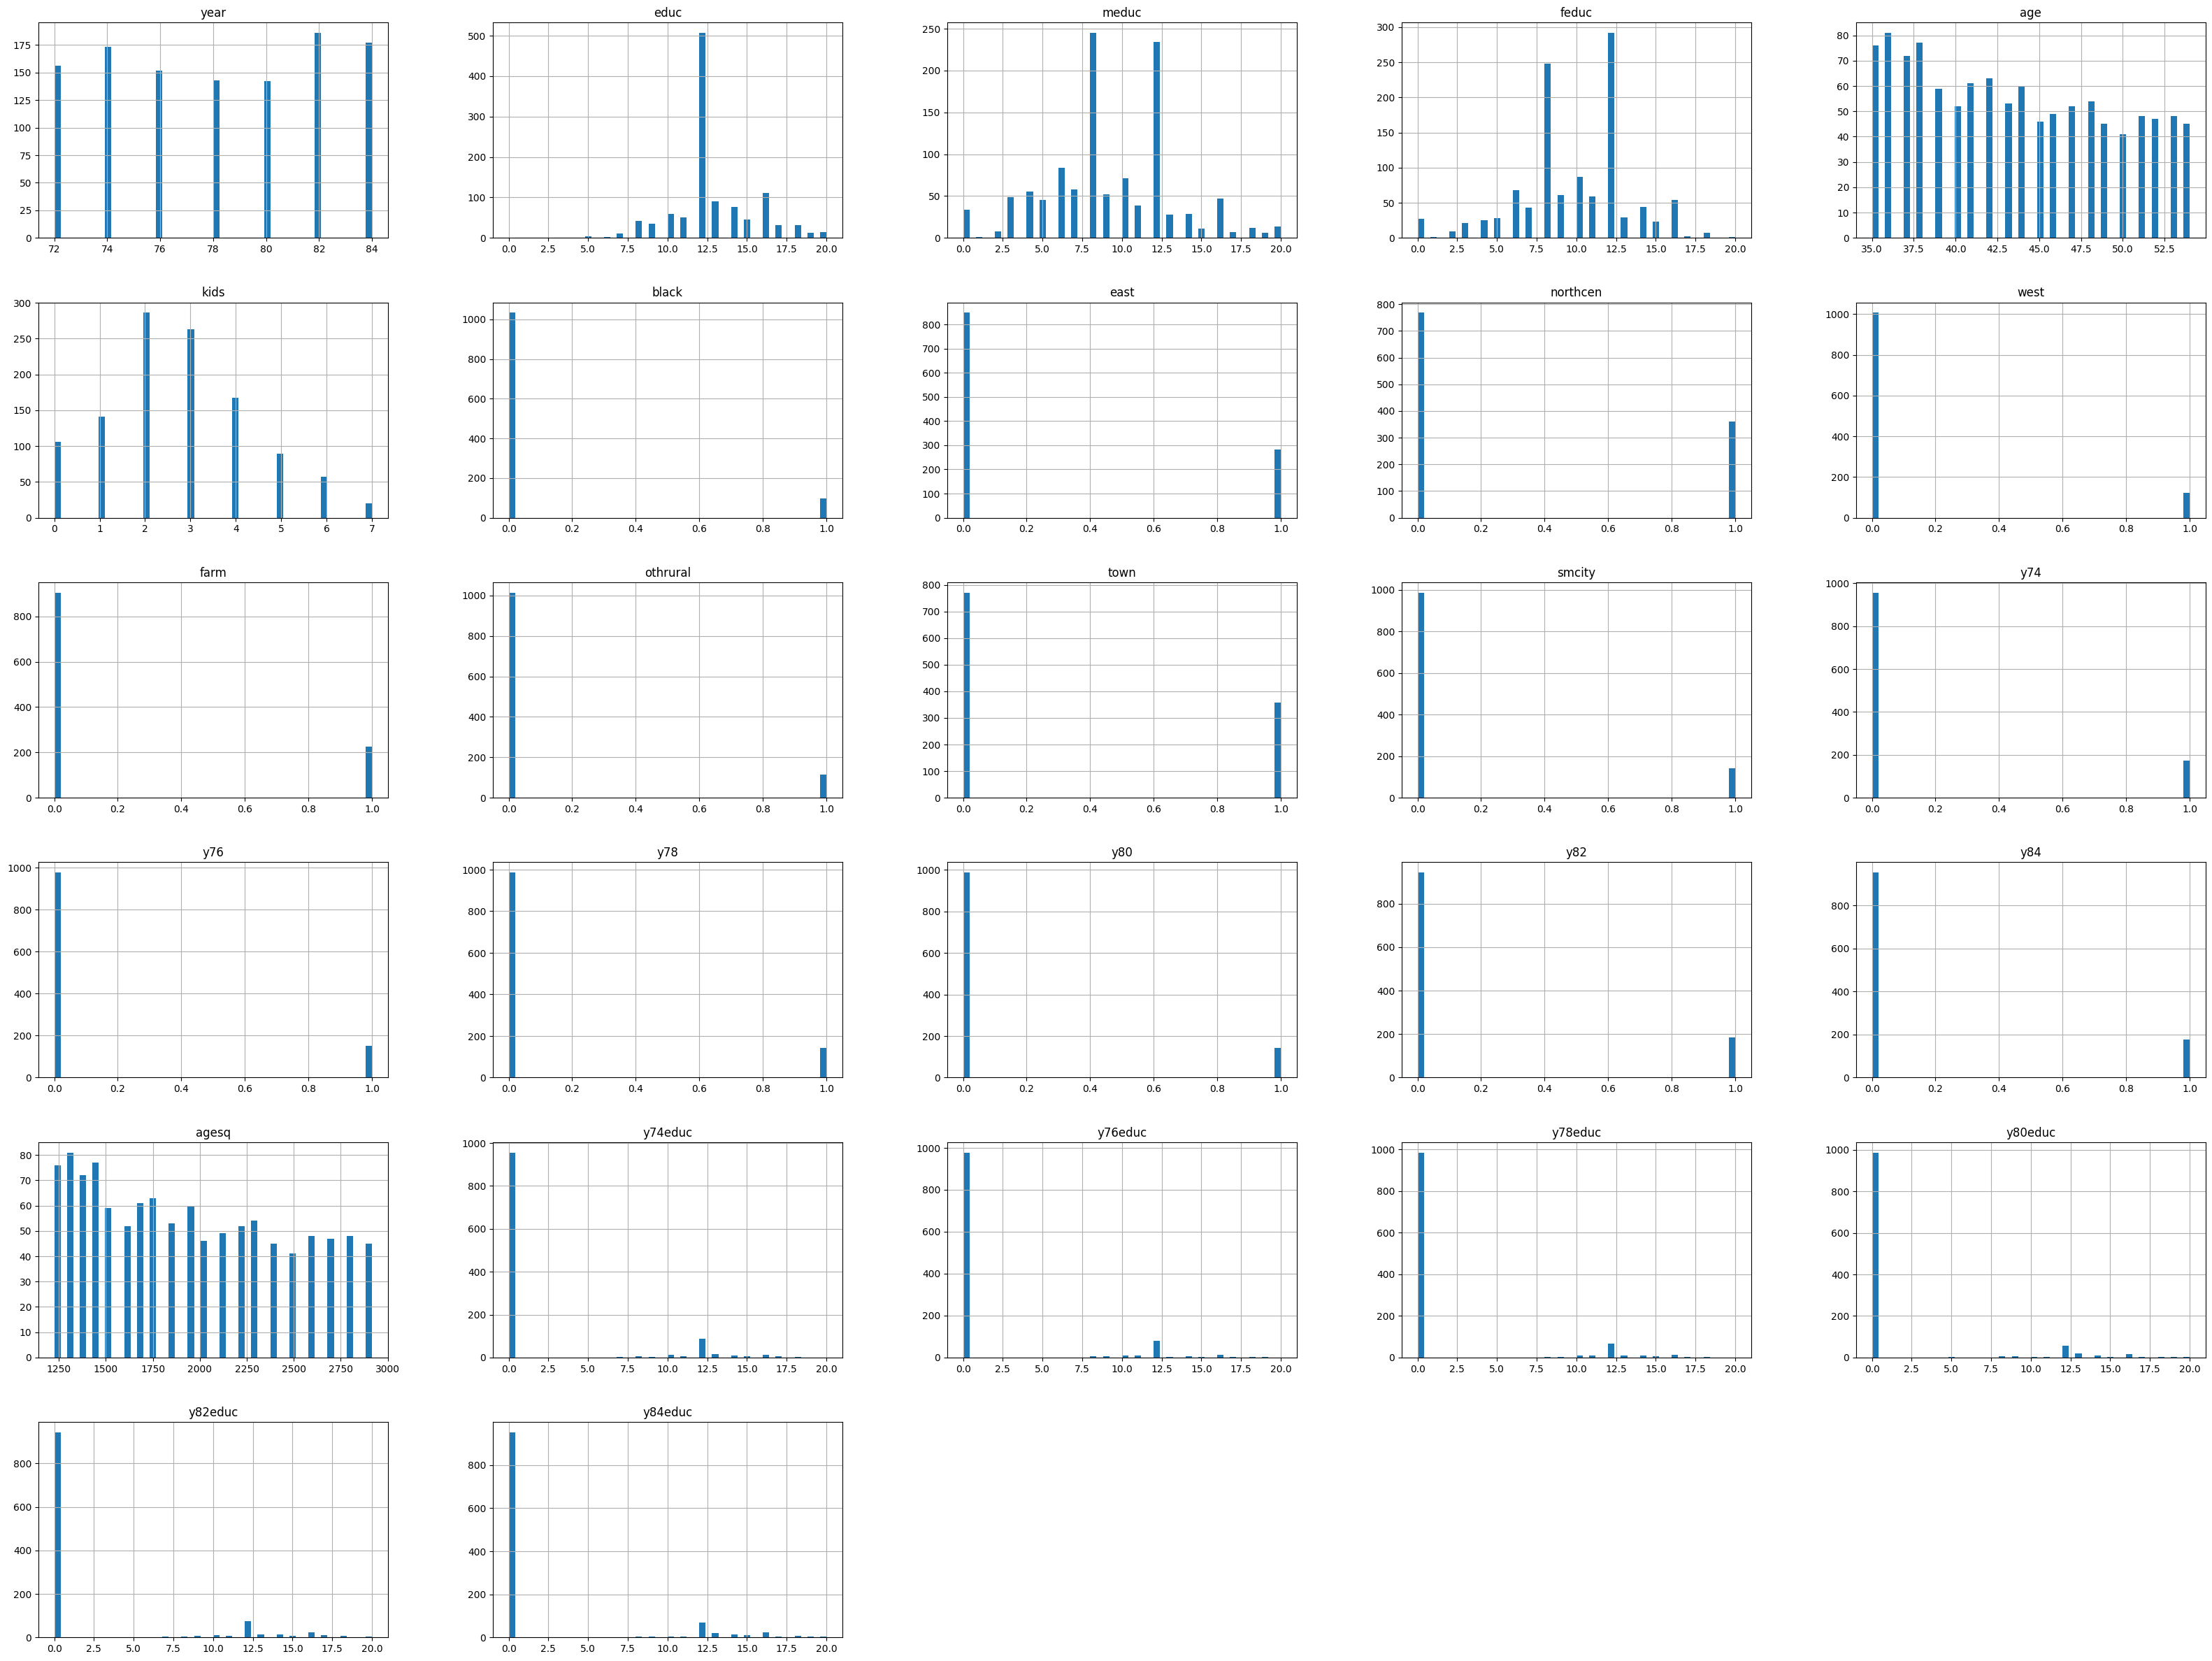

In [ ]:
# Plot the distribution of the variables
fertil.select_dtypes(include='number').hist(bins=50, figsize=(40, 30))
plt.savefig("fertil_attribute_histogram_plots")
plt.show()

In [ ]:
# Describe the variable kids
fertil["kids"].describe()

,kids
count,1129.000000
mean,2.743136
std,1.653899
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,7.000000


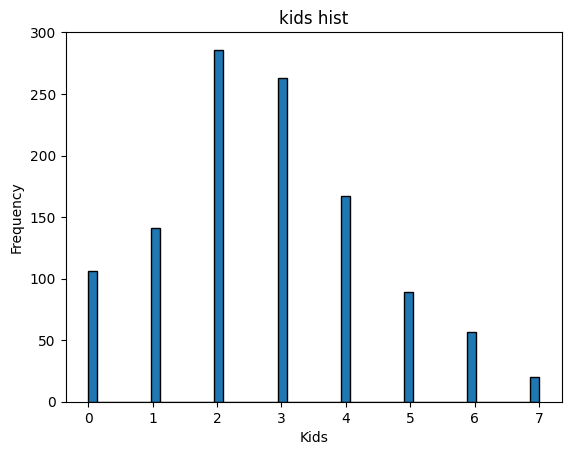

In [ ]:
# Plot a histogram for kids
plt.hist(fertil["kids"], bins=50, edgecolor='black')
plt.title("kids hist")
plt.xlabel("Kids")
plt.ylabel("Frequency")
plt.show()

#### Apply a linear regression model

kids = β₀ + β₁·educ + β₂·age + β₃·agesq + β₄·black + β₅·east + β₆·northcen + β₇·west + β₈·farm + β₉·othrural + β₁₀·town + β₁₁·smcity + β₁₂·y74 + β₁₃·y76 + β₁₄·y78  + β₁₅·y80 + β₁₆·y82 + β₁₇·y84 + ε


In [ ]:
# Fit the model
fit = smf.ols('kids ~ educ + age + agesq + black + east + northcen + west + farm + othrural + town + smcity + y74 + y76 + y78 + y80 + y82 + y84', data=fertil).fit()

# Show the results
print(fit.summary())
print(f"\nNote: R-squared: {fit.rsquared:.4f}")
print(f"\nNote: This linear regression model can explain {fit.rsquared * 100:.2f}% of variability of the dependent variable")

                            OLS Regression Results                            
Dep. Variable:                   kids   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     9.723
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           2.42e-24
Time:                        19:28:31   Log-Likelihood:                -2091.2
No. Observations:                1129   AIC:                             4218.
Df Residuals:                    1111   BIC:                             4309.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.7425      3.052     -2.537      0.0

####**Findings**

  1.   **A sharp decline in fertility in the early 1980s.** <br/>The coefficient on y82 is -0.5225 and is statistically significant at the 1% level (p = 0.003), indicating strong evidence that, holding all else constant, women in 1982 had on average 0.52 fewer children than comparable women in the base year, 1972. In other words, for a group of 100 similar women, this would correspond to approximately 52 fewer children in total. The statistical significance of this estimate suggests that the difference is unlikely to be due to random chance.

2.   **Woman with more education have fewer children.** <br/>The negative coefficient on education (-0.1284) is highly statistically significant (p < 0.001), suggesting that, holding all else constant, each additional year of education is associated with a reduction of approximately 0.13 children on average.